# Stanford Dogs Dataset Setup

This notebook provides a reproducible boilerplate for:
- locating the Stanford Dogs dataset locally or via KaggleHub,
- validating dataset structure,
- building train/test splits,
- generating analysis-ready DataFrames,
- and visual sanity checks.

It supports both dataset variants:
- split files (`lists/train_list.mat`, `lists/test_list.mat`), and
- folder-only datasets (`images/Images/<breed>/*.jpg`) by generating deterministic splits.


## 1) Dependencies and Imports

If your kernel is missing packages, uncomment the pip cell and run it once.


In [65]:
# %pip install -q kagglehub scipy matplotlib pillow pandas

from pathlib import Path
from typing import Dict, List, Sequence, Tuple
import random

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
from PIL import Image


## 2) Configuration

Keep all runtime knobs in one place for easier reuse.


In [66]:
# Reproducibility and split configuration
RANDOM_SEED = 42
TEST_FRACTION = 0.20
SAMPLE_PLOT_COUNT = 8

# Prefer local cache path first (offline-friendly)
LOCAL_DATASET_ROOT = Path(
    "/Users/ignacio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2"
)

KAGGLE_DATASET_HANDLE = "jessicali9530/stanford-dogs-dataset"


## 3) Dataset Resolution and Validation


In [67]:
def resolve_dataset_root(local_root: Path, kaggle_handle: str) -> Path:
    """Resolve dataset location, preferring local cache before network download."""
    if local_root.exists():
        print(f"Using local dataset cache: {local_root}")
        return local_root

    downloaded = Path(kagglehub.dataset_download(kaggle_handle))
    print(f"Downloaded dataset root: {downloaded}")
    return downloaded


def detect_image_root(images_dir: Path) -> Path:
    """Handle both images/ and images/Images layouts."""
    nested = images_dir / "Images"
    return nested if nested.exists() else images_dir


def validate_structure(dataset_root: Path) -> Dict[str, Path]:
    """Validate expected directories and return resolved paths."""
    images_dir = dataset_root / "images"
    image_root = detect_image_root(images_dir)
    annotations_dir = dataset_root / "annotations" / "Annotation"
    lists_dir = dataset_root / "lists"
    train_list = lists_dir / "train_list.mat"
    test_list = lists_dir / "test_list.mat"

    required_dirs = [image_root, annotations_dir]
    missing = [p for p in required_dirs if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing expected dataset directories: "
            + ", ".join(str(p) for p in missing)
        )

    return {
        "dataset_root": dataset_root,
        "image_root": image_root,
        "annotations_dir": annotations_dir,
        "train_list": train_list,
        "test_list": test_list,
    }


DATASET_ROOT = resolve_dataset_root(LOCAL_DATASET_ROOT, KAGGLE_DATASET_HANDLE)
paths = validate_structure(DATASET_ROOT)
HAS_MAT_SPLITS = paths["train_list"].exists() and paths["test_list"].exists()

print(f"Image root:       {paths['image_root']}")
print(f"Annotations root: {paths['annotations_dir']}")
print(f"MAT splits found: {HAS_MAT_SPLITS}")


Using local dataset cache: /Users/ignacio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2
Image root:       /Users/ignacio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2/images/Images
Annotations root: /Users/ignacio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2/annotations/Annotation
MAT splits found: False


## 4) Split Loading Utilities


In [68]:
def load_split_from_mat(
    mat_path: Path, image_root: Path
) -> Tuple[List[Path], List[int]]:
    """Load image paths and 1-based labels from Stanford Dogs .mat split files."""
    data = scipy.io.loadmat(mat_path)
    rel_paths = [x[0][0] for x in data["file_list"]]
    labels = [int(x[0]) for x in data["labels"]]  # labels are 1-based in source files
    img_paths = [image_root / rel for rel in rel_paths]
    return img_paths, labels


def list_breed_dirs(image_root: Path) -> List[Path]:
    return sorted([p for p in image_root.iterdir() if p.is_dir()])


def load_split_from_folders(
    image_root: Path,
    test_fraction: float = 0.2,
    seed: int = 42,
) -> Tuple[List[Path], List[int], List[Path], List[int]]:
    """Create deterministic per-class train/test splits from folder structure."""
    if not (0.0 < test_fraction < 1.0):
        raise ValueError("test_fraction must be between 0 and 1.")

    breed_dirs = list_breed_dirs(image_root)
    label_to_breed_local = {i + 1: p.name for i, p in enumerate(breed_dirs)}
    breed_to_label_local = {v: k for k, v in label_to_breed_local.items()}

    train_paths: List[Path] = []
    train_labels: List[int] = []
    test_paths: List[Path] = []
    test_labels: List[int] = []

    rng = random.Random(seed)

    for breed_dir in breed_dirs:
        images = sorted([p for p in breed_dir.rglob("*.jpg") if p.is_file()])
        if len(images) < 2:
            continue

        rng.shuffle(images)
        split_idx = int(len(images) * (1 - test_fraction))
        split_idx = min(max(split_idx, 1), len(images) - 1)

        label = breed_to_label_local[breed_dir.name]
        train_paths.extend(images[:split_idx])
        train_labels.extend([label] * split_idx)
        test_paths.extend(images[split_idx:])
        test_labels.extend([label] * (len(images) - split_idx))

    return train_paths, train_labels, test_paths, test_labels


## 5) Build Splits and Label Mapping


In [69]:
if HAS_MAT_SPLITS:
    train_paths, train_labels = load_split_from_mat(
        paths["train_list"], paths["image_root"]
    )
    test_paths, test_labels = load_split_from_mat(
        paths["test_list"], paths["image_root"]
    )
    split_source = "mat_files"
else:
    train_paths, train_labels, test_paths, test_labels = load_split_from_folders(
        paths["image_root"],
        test_fraction=TEST_FRACTION,
        seed=RANDOM_SEED,
    )
    split_source = "folder_split"

breed_dirs = [p.name for p in list_breed_dirs(paths["image_root"])]
label_to_breed: Dict[int, str] = {i + 1: breed for i, breed in enumerate(breed_dirs)}

num_classes = len(set(train_labels) | set(test_labels))

print(f"Split source:   {split_source}")
print(f"Train samples:  {len(train_paths):,}")
print(f"Test samples:   {len(test_paths):,}")
print(f"Classes:        {num_classes}")


Split source:   folder_split
Train samples:  16,418
Test samples:   4,162
Classes:        120


## 6) Create Analysis DataFrames


In [70]:
def build_index_df(
    paths: Sequence[Path], labels: Sequence[int], label_map: Dict[int, str]
) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "path": [str(p) for p in paths],
            "label": list(labels),
        }
    )
    df["breed"] = df["label"].map(label_map)
    return df


train_df = build_index_df(train_paths, train_labels, label_to_breed)
test_df = build_index_df(test_paths, test_labels, label_to_breed)

train_df.head(3), test_df.head(3)


(                                                path  label  \
 0  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 1  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 2  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 
                  breed  
 0  n02085620-Chihuahua  
 1  n02085620-Chihuahua  
 2  n02085620-Chihuahua  ,
                                                 path  label  \
 0  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 1  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 2  /Users/ignacio/.cache/kagglehub/datasets/jessi...      1   
 
                  breed  
 0  n02085620-Chihuahua  
 1  n02085620-Chihuahua  
 2  n02085620-Chihuahua  )

## 7) Quality Checks

Basic checks to catch data issues early.


In [71]:
missing_train_files = (~train_df["path"].map(lambda p: Path(p).exists())).sum()
missing_test_files = (~test_df["path"].map(lambda p: Path(p).exists())).sum()

print(f"Missing files in train split: {missing_train_files}")
print(f"Missing files in test split:  {missing_test_files}")

if missing_train_files or missing_test_files:
    raise RuntimeError("Some split entries point to missing files.")

label_dist = (
    train_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="train_count")
)
label_dist["breed"] = label_dist["label"].map(label_to_breed)
label_dist.head(10)


Missing files in train split: 0
Missing files in test split:  0


,label,train_count,breed
0,3,201,n02085936-Maltese_dog
1,10,191,n02088094-Afghan_hound
2,27,185,n02092002-Scottish_deerhound
3,108,175,n02112018-Pomeranian
4,20,174,n02090721-Irish_wolfhound
5,89,174,n02107683-Bernese_mountain_dog
6,107,174,n02111889-Samoyed
7,5,171,n02086240-Shih-Tzu
8,106,170,n02111500-Great_Pyrenees
9,104,168,n02111129-Leonberg


## 8) Visual Sanity Check


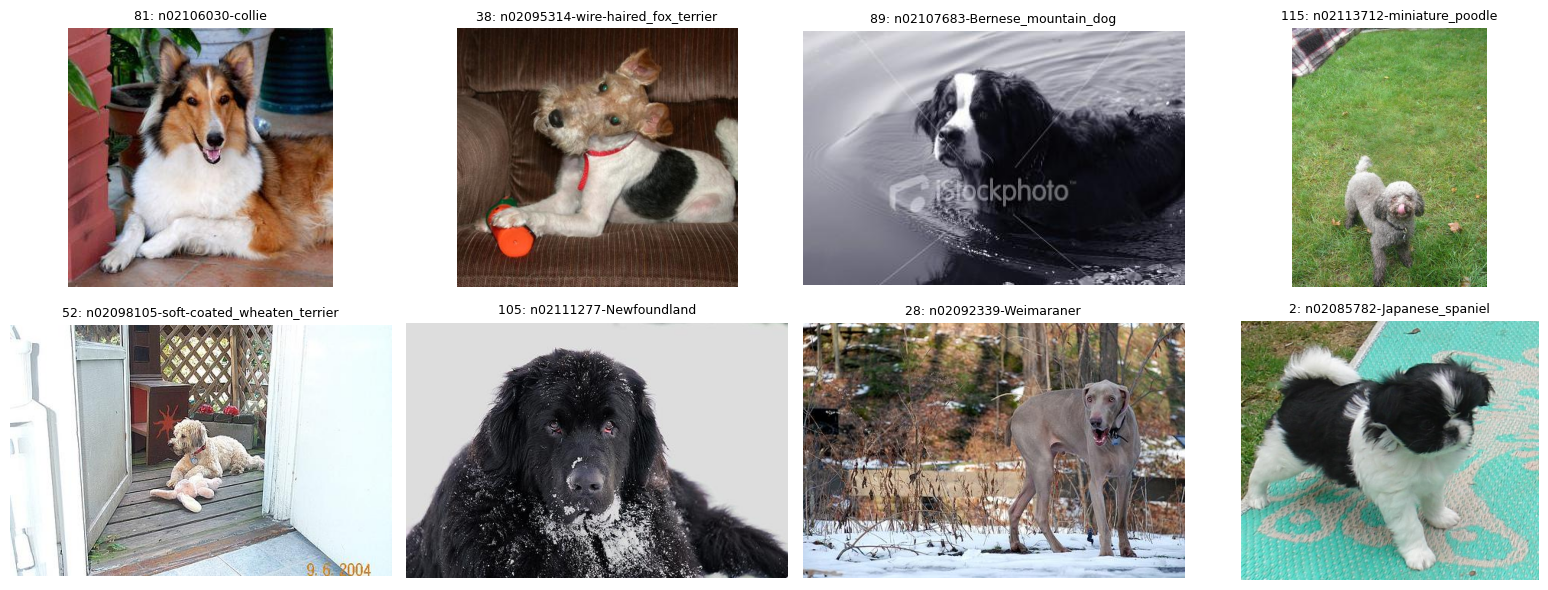

In [72]:
def show_random_samples(df: pd.DataFrame, n: int = 8, seed: int = 7) -> None:
    sample = df.sample(n=min(n, len(df)), random_state=seed)

    cols = 4
    rows_n = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(4 * cols, 3 * rows_n))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['label']}: {row['breed']}", fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample) :]:
        ax.axis("off")

    plt.tight_layout()


show_random_samples(train_df, n=SAMPLE_PLOT_COUNT, seed=RANDOM_SEED)


## 9) Optional Exports

Uncomment if you want persistent index files for training pipelines.


In [73]:
# train_df.to_csv(paths["dataset_root"] / "train_index.csv", index=False)
# test_df.to_csv(paths["dataset_root"] / "test_index.csv", index=False)
